In [1]:
import  numpy as np
import pandas as pd
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
x, y = make_circles(n_samples=1000, factor=0.1, noise=0.35, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [3]:
x.shape

(1000, 2)

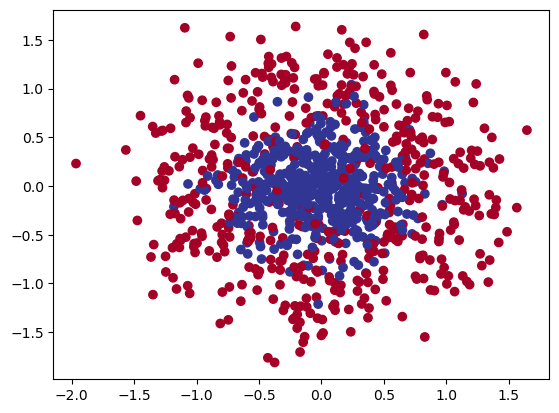

In [4]:
plt.scatter(x[:, 0], x[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [6]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [7]:
# plot boundary of decision tree
def plot_decision_boundary(model, x, y):
    x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
    y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=plt.cm.RdYlBu)

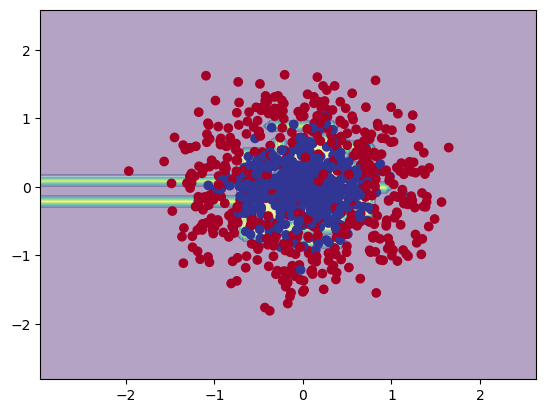

In [8]:
plot_decision_boundary(dt, x, y)

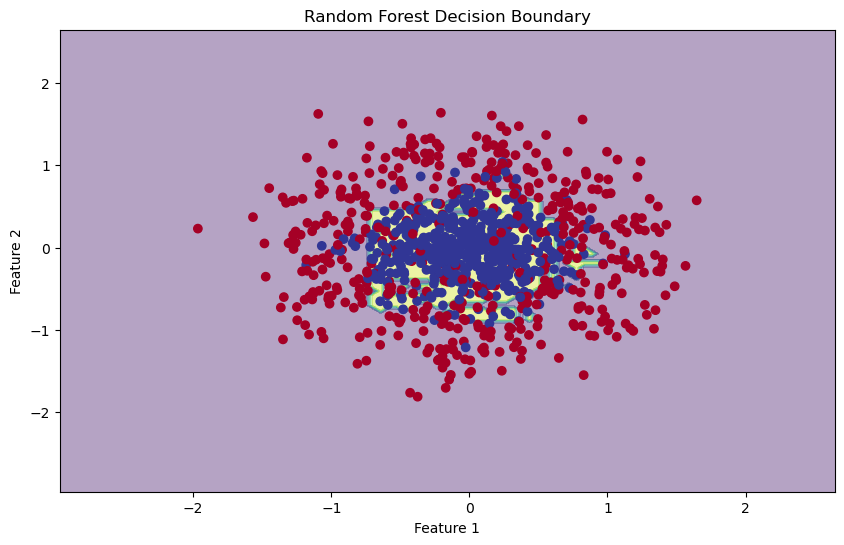

In [9]:
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)

plt.figure(figsize=(10, 6))
x_range = np.linspace(x[:, 0].min() - 1, x[:, 0].max() + 1, 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = rf.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.4)
plt.scatter(x[:, 0], x[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.title("Random Forest Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()